dqd sample in imedance bridge

In [51]:
from impedance_bridge_analysis.load_data import LoadData, get_parameter_snapshot_value
from impedance_bridge_analysis.plotting import Plotter

from impedance_bridge_analysis.calculation import bridge_calculation


import numpy as np
import matplotlib.pyplot as plt

%matplotlib ipympl

In [2]:
R_ref = 27e3

plotr = Plotter(theme="presentation")
calc = bridge_calculation(R_ref)

base_path = r"C:\Users\s.schreibing\Documents\qimchi_data\impedance_bridge\IHPCVD6 - DQD_v3\011_A1"

plot the 2d sweep of reference amplitude voltage and phase difference

In [3]:
experiment_name = r"\lockin_amplitude_ref and phase sweep - V_dut = 157 uV"
id = 8

loader = LoadData(data_path = base_path + experiment_name)
data = loader.load_zarr(run_id=id)

V_dut = get_parameter_snapshot_value(data, "V_dut")

min v_out_r: 85.71 uV


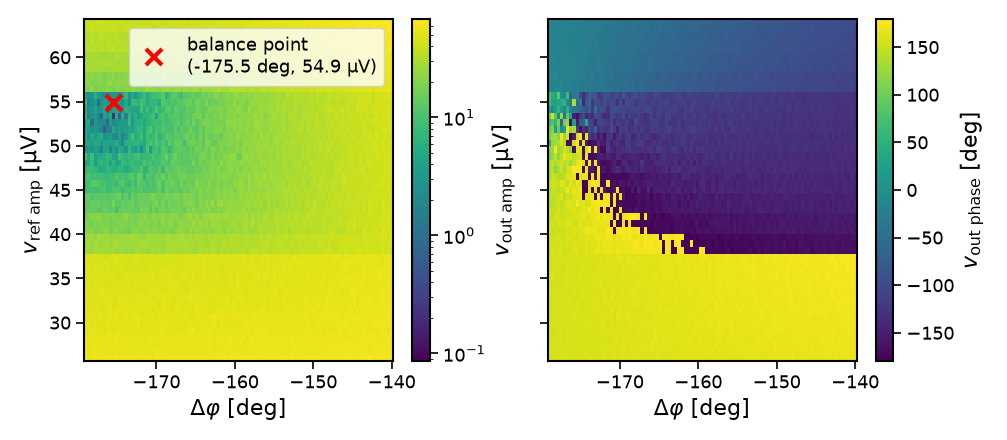

In [4]:
plotr.lockin_ref_phase_sweep(data, size_factor=1.6, balance_point=True, y_factor = 1e6, log_scale=True, save_path=rf"\plots\lockin_ref_phase_sweep_{V_dut:.2f}V_dut_bias_{id}_log.png")

In [5]:
# Capacitor modeled as parallel R and C
Z_dut = calc.calculate_impedance(data)

print(f"Impedance: {Z_dut:.2f} Ohm")

Impedance: 49390.75+3926.56j Ohm


go to zero dut bias

In [6]:
experiment_name = r"\lockin_amplitude_ref and phase sweep - V_dut = 0 uV"
id = 3

loader = LoadData(data_path = base_path + experiment_name)
data = loader.load_zarr(run_id=id)

V_dut = get_parameter_snapshot_value(data, "V_dut")

min v_out_r: 1031.69 uV


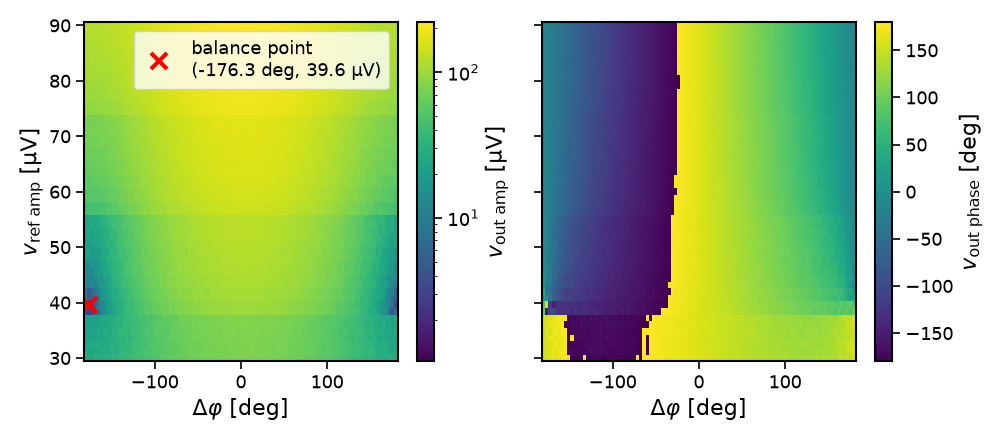

In [ ]:
plotr.lockin_ref_phase_sweep(data, size_factor=1.6, balance_point=True, y_factor = 1e6, log_scale=True, save_path=rf"\plots\lockin_ref_phase_sweep_{V_dut:.2f}V_dut_bias_{id}_log.png")

In [8]:
# Capacitor modeled as parallel R and C
Z_dut = calc.calculate_impedance(data)

print(f"Impedance: {Z_dut:.2f} Ohm")

Impedance: 68518.76+4472.15j Ohm


one expects a 180 degree shift for a purely resisitive device for destructive interference. Because the plot looks shit the sign of v_dut lockin amp was switched, then the phase diff is expected at zero.

In [46]:
experiment_name = r"\lockin_amplitude_ref and phase sweep - V_dut = 314 uV"
id = 1

loader = LoadData(data_path = base_path + experiment_name)
data = loader.load_zarr(run_id=id)

V_dut = get_parameter_snapshot_value(data, "V_dut")
f_lockin = get_parameter_snapshot_value(data, "lockin_frequency")

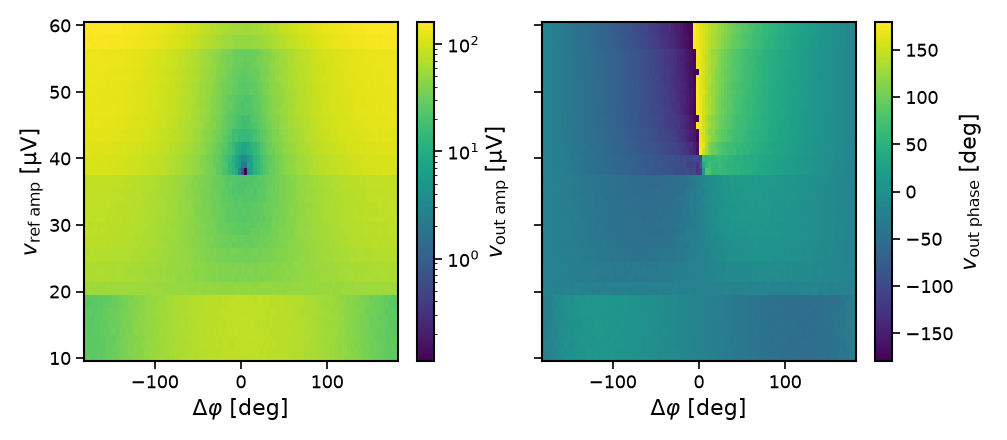

Impedance: 212077.23+20239.60j Ohm


In [47]:
plotr.lockin_ref_phase_sweep(data, size_factor=1.6, y_factor = 1e6, log_scale=True, save_path=rf"\plots\lockin_ref_phase_sweep_{V_dut:.2f}V_dut_bias_{id}_log.png")

# Capacitor modeled as parallel R and C
Z_dut = calc.calculate_impedance(data)
R, C = calc.calculate_RC_from_dut_Impedance(Z_dut, f_lockin)

#print(f"Capacitor modeled as parallel R and C: R = {R/1e3:.2f} kOhm, C = {C*1e12:.2f} pF")
print(f"Impedance: {Z_dut:.2f} Ohm")

In [48]:
experiment_name = r"\lockin_amplitude_ref gate sweep rail_voltages"
id = 4

loader = LoadData(data_path = base_path + experiment_name)
data = loader.load_zarr(run_id=id)

phase_diff = get_parameter_snapshot_value(data, "lockin_phase_diff")
print(f"Phase difference: {phase_diff:.2f} deg")

Phase difference: 3.00 deg


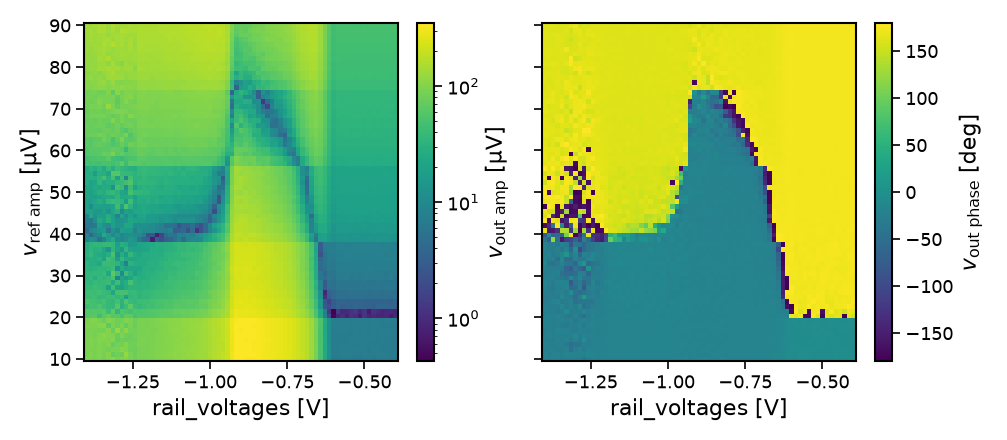

In [50]:
plotr.lockin_ref_gate_sweep(data, gate_label="rail_voltages",y_factor = 1e6, size_factor=1.6, log_scale=True, save_path=rf"\plots\lockin_ref_gate_sweep_rail_voltages_{id}_log.png")